In [1]:
import os


# Preparing data for fire impact analysis

This notebook demonstrates the process for processing input data for use with the fire impacts library.

The process is largely automated and, in many cases, the data is downloaded automatically from the publisher.

There are a few things that you will need, however:

* A catchment boundary for your area of interest (eg Shapefile, GeoJSON)
* A suitable, high resolution DEM for the area. The 1" SRTM derived DEM-H is a good option for most cases.
* The date of a fire event within the catchment,
* Several other datasets that you will need to manually download and store locally


## Installation

You will need a Python installation with the various libaries installed.

As a starting point, a base scientific Python installation that includes `numpy`, `pandas`, `jupyter`, `matplotlib`. For Windows users, the easiest way to set up such an environment is to use Anaconda Python, or miniconda.

This base environment should be extended with specific libraries that are used by the fire impacts library. These are listed in `requirements.txt` and can be installed using `pip` from a command prompt:

```
cd <directory-with-library>
pip install -r requirements.txt
```

Finally, the fire impacts library itself should be installed. If you have cloned the git repository, you can install from your local copy. From the command prompt:

```
cd <directory-with-library>
pip install -e .
```

When the installation has completed, the following import statements should run without error

In [2]:
from fire_impacts import FireImpactsProject
from fire_impacts.pre import project, topography, severity, soil, rusle

## Logging

We use logging statements to provide feedback on progress through various steps. This allows you to tailor what level of information you see by setting a log 'level':

* `DEBUG`: Low level information about progress
* `INFO`: General progress updates
* `WARNING`: Problems or potential problems that the system can handle
* `EROR`: Problems that prevent the system from running correctly

When you set a log level, you will see those messages as well as the more serious ones. So if you choose `INFO`, you will also see `WARNING` and `ERROR` messages. If you choose `WARNING`, you will also see `ERROR`.

In [3]:
import logging
logging.basicConfig(level=logging.INFO,format='%(asctime)s - %(name)s - %(levelname)s - %(message)s')

## Projects

We organise all the data related to a study in a project directory. This should generally be a *new* directory that will be populated with data that has been computed with the library. The library will manage the subdirectories and data within the main project directory.

In Python, we use a `FireImpactsProject` object to represent this directory and all the data stored within it

Here, we create a new project in the current directory. **Note:** In this case we will delete (`clear`) any existing data in that directory.

By default, *current directory* here is the directory this Notebook is saved in.


**Try** running this next code not on OneDrive and see if we still get hte access error

In [4]:

proj = FireImpactsProject('\\zz_TempDump\\fire-impacts-data',clear=True)


2025-11-21 15:11:50,987 - fire_impacts.pre.project - INFO - Clearing existing project folder: \zz_TempDump\fire-impacts-data


## Catchment areas

A project can store data related to one or more catchments.

Catchments are added to the project by providing a boundary coverage (eg a Shapefile or a GeoJSON file).

Here, we add a small example catchment, from the `test_data` directory, but you can use your own.

**Note:** The boundary coverage should include a coordinate reference system (CRS). This is the CRS that will be used for all other data stored in relation to this catchment in the project.

In [5]:
proj.add_catchment('..\\test_data\\example_small_catchment.json')

In [6]:
proj.catchments

['example_small_catchment']

## Pro processing steps

We will now work through each step of data pre-processing to support for the fire impacts modelling:

* **Topography**: Determine various topographic properties from a DEM, including headwater catchments used to model debris flow triggers
* **Fire severity**: Analyse satellite information to determine the intensity of a historical fire event
* **Soils**: Extract relevant soil properties from the Soil and Landscape Grid of Australia
* **RUSLE**: Compute RUSLE terms (K, L, S and C), including fire modified versions of K and C

There is some flexibility to run these processes in different orders, except that the RUSLE processing should be done _after_ other processes.

The following sections describe each process and the data required.

## Topography

The topographic processing uses a DEM to identify relevant topographic properties required for the modelling.

This includes:

* Headwater catchment delineation, used to model the areas likely to trigger debris flow, and
* Slope and hillslope length, used in the parameterisation of erosion modelling.

You will need a suitable DEM. We have provided a DEM for the example catchment, but if you are using your own catchment you need a DEM covering the entire catchment.

If using the [national 1" DEM](https://ecat.ga.gov.au/geonetwork/srv/eng/catalog.search#/metadata/72759), use the hydrologically enforced DEM (DEM-H).


In [7]:
DEM_FILENAME='..\\test_data\\example_dem.tif'

In [8]:
topography.extract_catchment_dems(proj,DEM_FILENAME)

2025-11-21 15:11:51,162 - fire_impacts.pre.topography - INFO - Extracting 1 catchment DEMs
2025-11-21 15:11:51,163 - fire_impacts.pre.topography - INFO - Extracting DEM for catchment: example_small_catchment
C:\Users\richard.farr\OneDrive - Alluvium Consulting Australia\Documents\WorkItems\Projects\0124114_Bushfire_WQ_Modelling\WaterRA_Bushfire_Modeling\fire_impacts\pre\util.py:38: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  catchment = catchment.to_crs(raster_crs).buffer(raster_res[0]*2)
2025-11-21 15:11:52,551 - fire_impacts.pre.util - INFO - Reprojecting raster from EPSG:4326 to EPSG:4326
2025-11-21 15:11:52,558 - rasterio._env - WARNING - CPLE_NotSupported in driver GTiff does not support creation option RES
2025-11-21 15:11:52,564 - fire_impacts.pre.util - INFO - Reprojecting clipped raster to: \zz_TempDump\fire-impacts-data\Catchments\exampl

In [9]:
headwaters = topography.extract_headwaters(proj)

2025-11-21 15:11:52,581 - fire_impacts.pre.project - INFO - Processing 1 catchments
2025-11-21 15:11:52,581 - fire_impacts.pre.topography - INFO - Extracting headwaters for catchment: example_small_catchment
2025-11-21 15:11:52,584 - root - INFO - Computing catchment slope
2025-11-21 15:11:52,585 - fire_impacts.pre.topography - WARNING - CRS should be in meters, was unknown. Applying crs_unit_to_metres conversion (111000.000000)
2025-11-21 15:11:52,593 - fire_impacts.pre.topography - INFO - Threshold # cells: 21 (20000.000000 m^2)
2025-11-21 15:11:52,596 - fire_impacts.pre.topography - INFO - Loading DEM from \zz_TempDump\fire-impacts-data\Catchments\example_small_catchment\Topography\DEM.tif
2025-11-21 15:11:52,599 - fire_impacts.pre.topography - INFO - Filling pits
2025-11-21 15:11:52,604 - fire_impacts.pre.topography - INFO - Filling depressions
2025-11-21 15:11:52,719 - fire_impacts.pre.topography - INFO - Resolving flats
2025-11-21 15:11:52,858 - fire_impacts.pre.topography - INFO

In [10]:
headwaters['example_small_catchment']

,ID,Area_m2,Area_ha,PP_Flow_acc,PourPt_X,PourPt_Y,Dist,Move_dist,X_EndP,Y_EndP
0,1,0.0,0.0,21.0,145.959861,-38.069028,0.1,0.0,145.92125,-38.100972
1,2,0.0,0.0,23.0,145.960417,-38.069028,0.1,0.0,145.92125,-38.100972
2,3,0.0,0.0,22.0,145.961806,-38.069028,0.1,0.0,145.92125,-38.100972
3,4,0.0,0.0,22.0,145.959028,-38.069583,0.0,0.0,145.92125,-38.100972
4,5,0.0,0.0,23.0,145.952361,-38.069861,0.0,0.0,145.92125,-38.100972
...,...,...,...,...,...,...,...,...,...,...
243,244,0.0,0.0,23.0,145.922083,-38.101528,0.0,0.0,145.92125,-38.100972
244,245,0.0,0.0,22.0,145.966250,-38.102083,0.0,0.0,145.92125,-38.100972
245,246,0.0,0.0,21.0,145.930139,-38.102361,0.0,0.0,145.92125,-38.100972
246,247,0.0,0.0,22.0,145.950417,-38.102361,0.0,0.0,145.92125,-38.100972


## Aside: Visualising data

The `proj` object includes a convenience function for visualising the processed data layers:

2025-11-21 15:11:54,282 - fire_impacts.pre.project - INFO - Processing 1 catchments


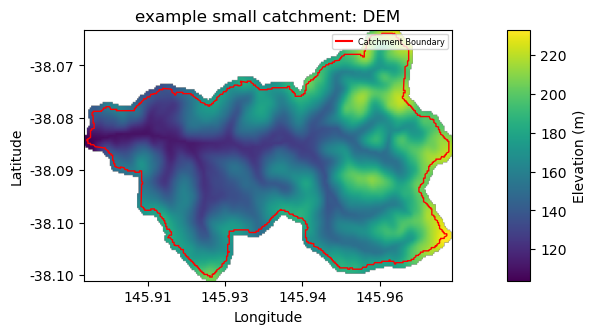

In [11]:
proj.plot_catchment_raster('Topography','DEM.tif')

2025-11-21 15:11:54,673 - fire_impacts.pre.project - INFO - Processing 1 catchments


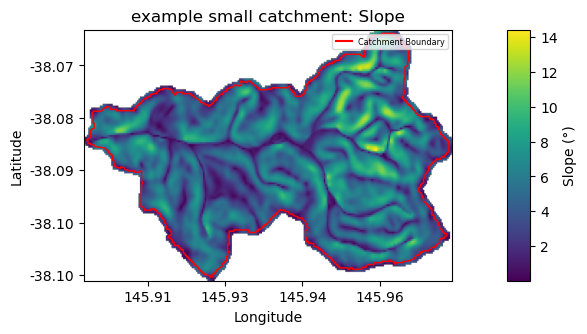

In [12]:
proj.plot_catchment_raster('Topography','Slope')

2025-11-21 15:11:55,067 - fire_impacts.pre.project - INFO - Processing 1 catchments


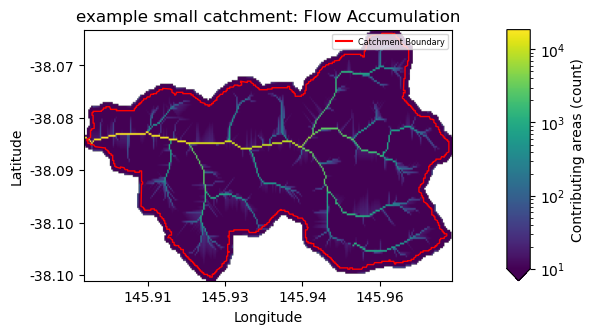

In [13]:
proj.plot_catchment_raster('Topography','Flow_accumulation')

## Aside: Function documentation

Most of the library functions include documentation describing the process, the function parameters and any return values

You can access the help in Jupyter with the `?` operator, for example:

```
topography.extract_headwaters?
```

In [14]:
topography.extract_headwaters?

Signature:
topography.extract_headwaters(
    project: fire_impacts.pre.project.FireImpactsProject,
    name: str = None,
    threshold_m2: float = 20000,
    crs_unit_to_metres: float = None,
)
Docstring:
Delinate headwaters for a catchment based on a flow accumulation threshold.

Parameters:
- project (dict): Dictionary containing the project folder structure.
- name (str): Name of the catchment to process. If None, process all catchments.
- threshold_m2 (float): Threshold area in square meters for headwaters. Default is 20,000 m^2.

Writes:
- Headwaters.shp: Shapefile containing the headwaters polygons.
- Headwaters.tif: Raster file containing the headwaters polygons.
- Headwaters.csv: CSV file containing the headwaters summary
- Flow_accumulation.tif: Raster file containing the flow accumulation data.
- Stream_Network.tif: Raster file containing the stream network data.
- Slope.tif: Raster file containing the slope data.

Returns:
- pd.DataFrame: DataFrame containing the headwaters

## Fire Severity

In [15]:
fire_start_date = '2019-01-15'  # Set fire start date (the date that fire started)
fire_end_date = '2019-03-07'    # Set fire end date (the date that fire ended)

In [16]:
severity.calculate_fire_severity(
    project=proj,
    catchment=None,
    fire_start_date=fire_start_date,
    fire_end_date=fire_end_date,
)


2025-11-21 15:11:55,858 - fire_impacts.pre.project - INFO - Processing 1 catchments
2025-11-21 15:11:55,967 - fire_impacts.pre.severity - INFO - No start date for pre-fire data provided. Defaulting to 90 days before fire start date.
2025-11-21 15:11:55,967 - fire_impacts.pre.severity - INFO - No end date for post-fire data provided. Defaulting to 90 days after fire end date.
2025-11-21 15:11:55,968 - fire_impacts.pre.severity - INFO - Bounding box not provided. Calculating bounding box from shapefile with 10km buffer.
2025-11-21 15:11:55,982 - fire_impacts.pre.severity - INFO - Alternative resolution (degrees): 0.000180 (was 20.000000m)
2025-11-21 15:11:55,983 - fire_impacts.pre.severity - INFO - Calculating Pre_fire NBR for example_small_catchment
2025-11-21 15:11:55,985 - fire_impacts.pre.severity - INFO - calc_nbr(): loading sentinel data for Prefire (2018-10-17 to 2019-01-14)
2025-11-21 15:11:56,356 - fire_impacts.pre.severity - INFO - Found 22 sentinel datasets for Prefire
C:\User

{'example_small_catchment': None}

## Soils



In [17]:
ARIDITY=r'..\\test_data\\Aridity_PT.tif'

In [18]:
API_KEY = os.environ.get('TERN_API_KEY')

soil.download_soil_data_stac(proj, api_key=API_KEY)

# Extract aridity data for each catchment
soil.extract_aridity_data(proj,aridity_raster=ARIDITY)

2025-11-21 15:12:46,786 - fire_impacts.pre.project - INFO - Processing 1 catchments
2025-11-21 15:12:54,685 - fire_impacts.pre.soil - INFO - Processing catchment: example_small_catchment with 8 grids found
2025-11-21 15:12:54,688 - fire_impacts.pre.soil - INFO - Using GDAL API key from temporary file C:\Users\RICHAR~1.FAR\AppData\Local\Temp\tmpahpu44oegdal_api_key.txt
2025-11-21 15:12:54,689 - fire_impacts.pre.soil - INFO - Downloading BDW_000_005_EV_N_P_AU_TRN_N_20230607.tif
C:\Users\richard.farr\OneDrive - Alluvium Consulting Australia\Documents\WorkItems\Projects\0124114_Bushfire_WQ_Modelling\WaterRA_Bushfire_Modeling\fire_impacts\pre\util.py:38: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  catchment = catchment.to_crs(raster_crs).buffer(raster_res[0]*2)
2025-11-21 15:12:56,782 - fire_impacts.pre.util - INFO - Reprojecting raster from EPSG:4326 

## RUSLE



In [19]:
c_factor_path='..\\test_data\\c_factor_g94.tif'
k_factor_path='..\\test_data\\k_factor_g94.tif'


In [20]:
rusle.compute_adjusted_k_c(proj,catchment=None,c_factor_fn=c_factor_path,k_factor_fn=k_factor_path)

2025-11-21 15:13:07,640 - fire_impacts.pre.project - INFO - Processing 1 catchments
C:\Users\richard.farr\OneDrive - Alluvium Consulting Australia\Documents\WorkItems\Projects\0124114_Bushfire_WQ_Modelling\WaterRA_Bushfire_Modeling\fire_impacts\pre\util.py:38: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  catchment = catchment.to_crs(raster_crs).buffer(raster_res[0]*2)
2025-11-21 15:13:07,967 - fire_impacts.pre.util - INFO - Reprojecting raster from EPSG:4283 to EPSG:4326
2025-11-21 15:13:08,009 - rasterio._env - WARNING - CPLE_NotSupported in driver GTiff does not support creation option RES
2025-11-21 15:13:08,015 - fire_impacts.pre.util - INFO - Reprojecting clipped raster to: \zz_TempDump\fire-impacts-data\Catchments\example_small_catchment\Erodibility\C_factor.tif
C:\Users\richard.farr\OneDrive - Alluvium Consulting Australia\Documents\WorkItem

In [21]:

results = rusle.compute_lsi(proj)


2025-11-21 15:13:08,347 - fire_impacts.pre.project - INFO - Processing 1 catchments
2025-11-21 15:13:08,348 - fire_impacts.pre.rusle - INFO - Computed LSI for catchment: example_small_catchment
2025-11-21 15:13:08,435 - fire_impacts.pre.rusle - INFO - LS factor computed for catchment: example_small_catchment


## Summary information for Fire Severity

In [22]:
summary = project.summary_stats(proj)

2025-11-21 15:13:08,443 - fire_impacts.pre.project - INFO - Processing 1 catchments
2025-11-21 15:13:08,470 - fire_impacts.pre.project - INFO - Processing 248 polygons for 11 layers in example_small_catchment
2025-11-21 15:13:08,471 - root - INFO - Processing Slope from Slope.tif
2025-11-21 15:13:10,113 - root - INFO - Processing dNBR from dNBR.tif
2025-11-21 15:13:11,363 - root - INFO - Processing Aridity from Aridity.tif
2025-11-21 15:13:12,849 - root - INFO - Processing BDW_000_005_EV_N_P_AU_TRN_N_20230607 from BDW_000_005_EV_N_P_AU_TRN_N_20230607.tif
2025-11-21 15:13:14,121 - root - INFO - Processing BDW_005_015_EV_N_P_AU_TRN_N_20230607 from BDW_005_015_EV_N_P_AU_TRN_N_20230607.tif
2025-11-21 15:13:15,487 - root - INFO - Processing CLY_000_005_EV_N_P_AU_TRN_N_20210902 from CLY_000_005_EV_N_P_AU_TRN_N_20210902.tif
2025-11-21 15:13:16,776 - root - INFO - Processing CLY_005_015_EV_N_P_AU_TRN_N_20210902 from CLY_005_015_EV_N_P_AU_TRN_N_20210902.tif
2025-11-21 15:13:18,081 - root - INFO

In [23]:
summary['example_small_catchment']

,ID,Slope_mean,Slope_max,Slope_min,Slope_median,Slope_std,dNBR_mean,dNBR_max,dNBR_min,dNBR_median,...,SND_005_015_EV_N_P_AU_TRN_N_20210902_mean,SND_005_015_EV_N_P_AU_TRN_N_20210902_max,SND_005_015_EV_N_P_AU_TRN_N_20210902_min,SND_005_015_EV_N_P_AU_TRN_N_20210902_median,SND_005_015_EV_N_P_AU_TRN_N_20210902_std,dNBR_mean_fmtd,dNBR_max_fmtd,dNBR_min_fmtd,dNBR_median_fmtd,dNBR_std_fmtd
0,1,7.277140,10.805540,2.985693,7.477023,2.572590,0.011110,0.327712,-0.133339,-0.025995,...,66.500000,67.0,66.0,66.5,0.500000,11.109835,327.712268,0.000000,0.000000,120.759001
1,2,8.470322,11.824585,2.710411,9.024028,2.964884,0.091660,0.324026,-0.105561,0.099720,...,64.666667,66.0,63.0,65.0,1.247219,91.659823,324.026316,0.000000,99.719942,113.677548
2,3,4.347613,6.730673,1.397475,4.364116,1.467525,0.213938,0.405631,0.018121,0.214855,...,63.000000,63.0,63.0,63.0,0.000000,213.938072,405.630797,18.121421,214.854777,72.720831
3,4,6.134277,9.783648,1.067913,6.166992,2.433226,0.182204,0.418693,-0.070695,0.176639,...,68.500000,69.0,68.0,68.5,0.500000,182.204211,418.693483,0.000000,176.639169,107.209146
4,5,3.719271,5.002630,0.518340,4.131714,1.332346,0.071063,0.185734,-0.059383,0.073161,...,65.500000,66.0,65.0,65.5,0.500000,71.063265,185.733616,0.000000,73.160723,67.009704
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
243,244,2.835031,4.103693,1.166650,2.988143,0.849174,0.189432,0.334757,0.096019,0.183972,...,63.000000,64.0,62.0,63.0,0.707107,189.432081,334.756613,96.019119,183.971912,58.872946
244,245,2.597015,3.492471,1.892720,2.501483,0.541188,0.212618,0.392298,-0.006401,0.230229,...,64.000000,66.0,62.0,64.0,2.000000,212.617922,392.297566,0.000000,230.229467,107.464767
245,246,4.280627,5.131558,2.235763,4.355707,0.792827,0.132851,0.311493,-0.021831,0.128019,...,64.333333,65.0,63.0,65.0,0.942809,132.850697,311.493248,0.000000,128.019437,91.762293
246,247,1.331236,1.894817,0.756084,1.391068,0.291921,0.103438,0.434944,-0.210570,0.072692,...,65.000000,66.0,63.0,66.0,1.414214,103.437872,434.943765,0.000000,72.692320,155.346733
